# Avaliação Prática Etapa 1

### Desafios Selecionados

Para a primeira etapa da avaliação prática, eu escolhi resolver o desafio 1.

### Import das bibliotecas e dependências

Antes de começar a resolução dos exercícios de fato, será necessário importar as seguintes bibliotecas:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from IPython.display import display
from xgboost import XGBClassifier


## Desafio 1

### Questões:


### 1. Existem valores ausentes ou inconsistentes no dataset? Se sim, escolha e justifique uma estratégia de tratamento.


In [3]:
file_path = '../data/heart.csv' if os.path.exists('../data/heart.csv') else 'data/heart.csv'
df = pd.read_csv(file_path)

print(df.isnull().sum())
print(f'\nrepetições: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(df.shape)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

repetições: 723
(302, 14)


Ao analisar o dataset, constatou-se que não há valores nulos, e então dispensou-se a utilização de técnicas de imputação artificial visando manter íntegro o contexto clínico primário da saúde vascular.

Porém, contabilizou-se centenas de registros duplicados. Tendo em vista que a modelagem preditiva será arquitetada em algoritmos como Random Forest, manter repetições neste volume poderia gerar um viés incorreto no treinamento, forçando a máquina a memorizar padrões duplicados em vez de aprender as correlações clínicas reais. Como consequência, optou-se pelo imediato descarte dessas duplicatas, propiciando que o treinamento utilize matrizes com pacientes clinicamente independentes.

### 2. Plote histogramas e boxplots das variáveis numéricas. Quais apresentam distribuição assimétrica ou outliers relevantes?


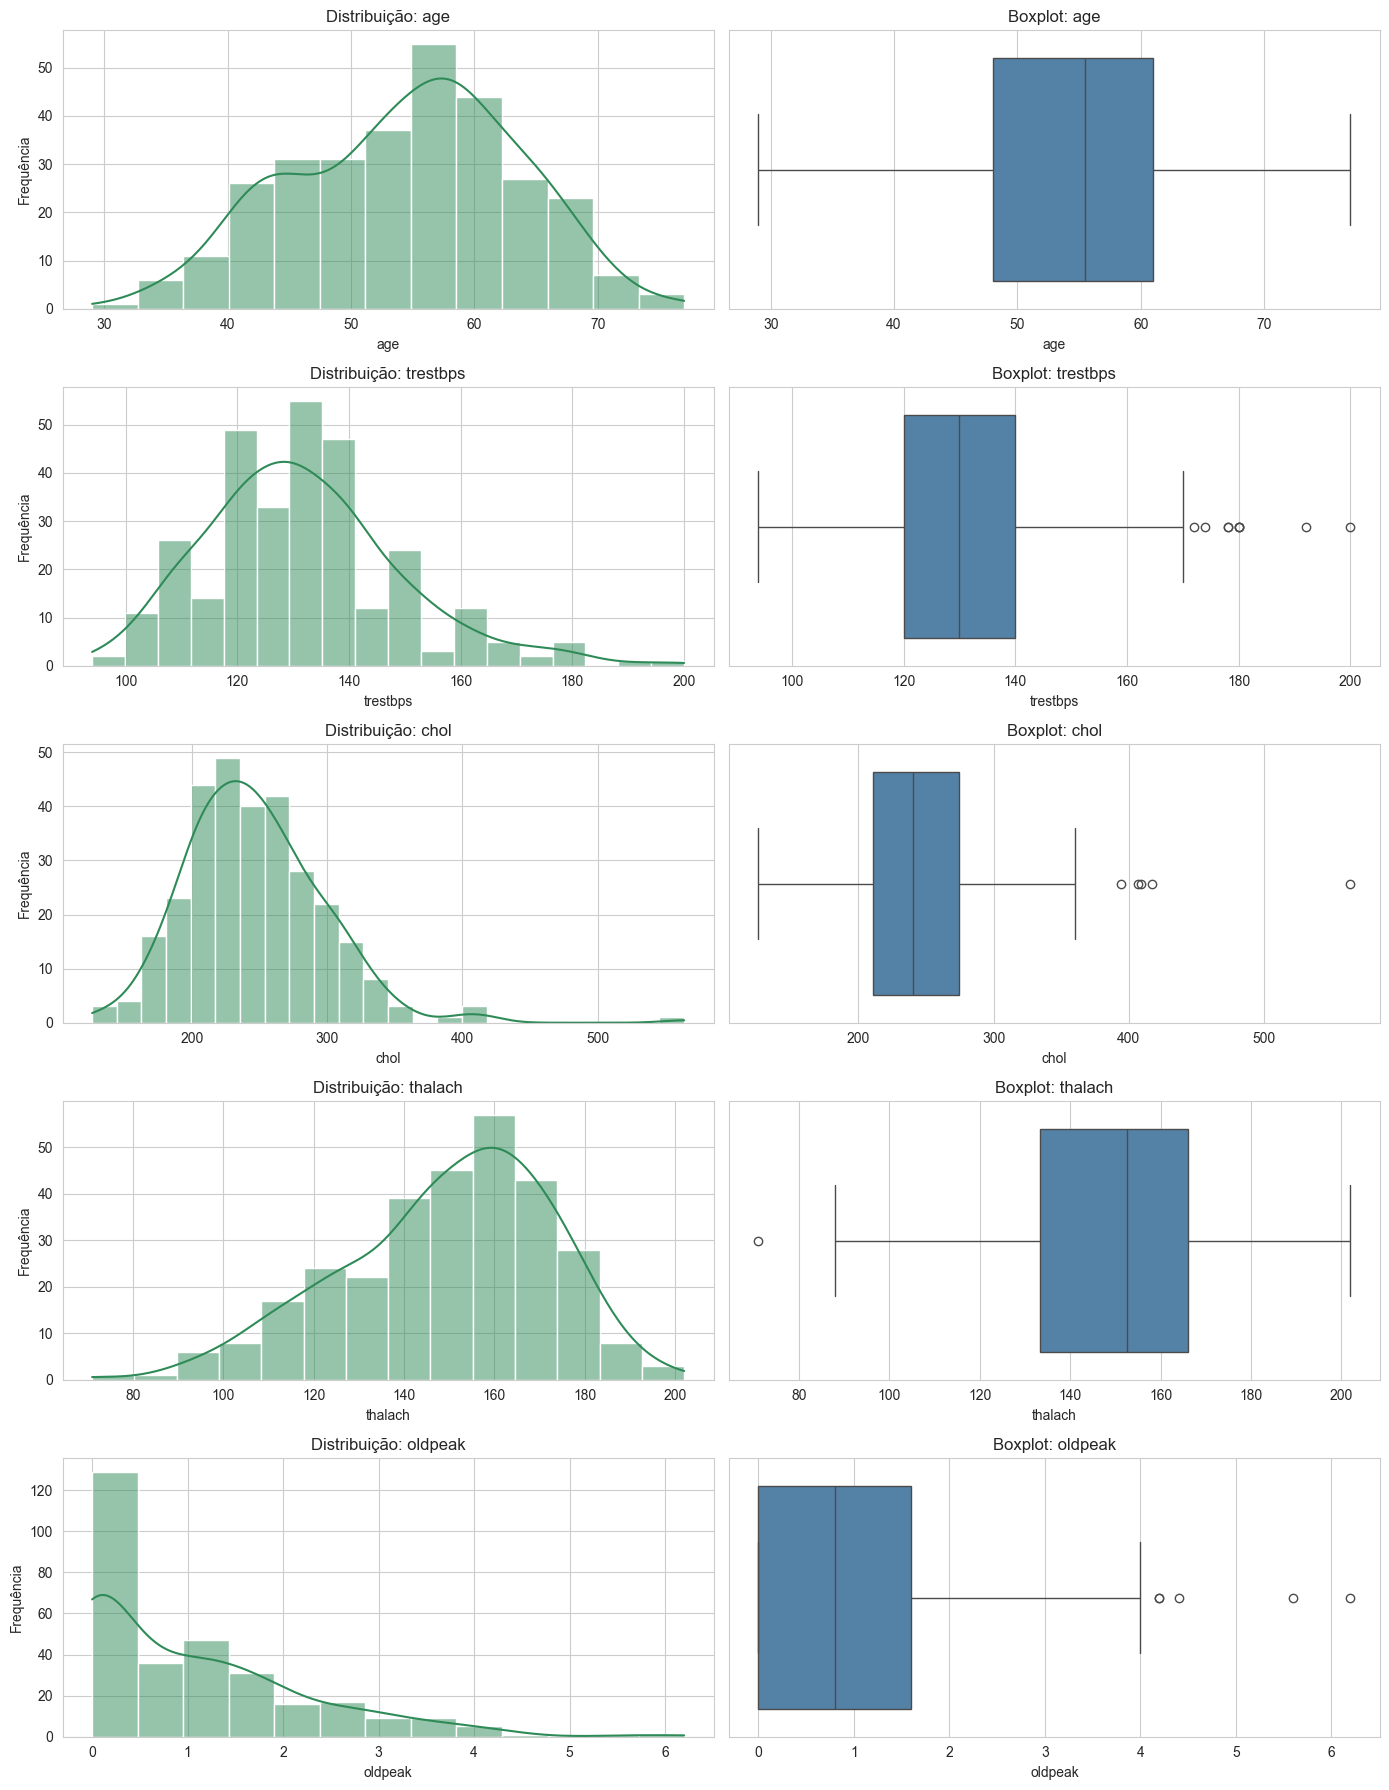

In [4]:
custom_palette = ['#2E8B57', '#4682B4']
sns.set_palette(custom_palette)
sns.set_style('whitegrid')

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 18))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color=custom_palette[0])
    axes[i, 0].set_title(f'Distribuição: {col}')
    axes[i, 0].set_ylabel('Frequência')
    
    sns.boxplot(x=df[col], ax=axes[i, 1], color=custom_palette[1])
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


Por meio de histogramas e boxplots, analisou-se as distribuições e a presença de outliers nas variáveis numéricas.

Constatou-se que a idade e a frequência cardíaca máxima apresentam boa simetria, possuindo poucos valores extremos na amostra.

Em contrapartida, notou-se uma assimetria com direcionamento superior nas distribuições do colesterol e da pressão arterial, com ambas reunindo muitos outliers acima dos quartis comuns. É possível perceber que tentar limpar essas distorções representadas no boxplot destruiria a complexidade que o modelo deve analisar, visto que esses picos representam cenários reais da instabilidade cardiovascular do paciente. Como consequência, optou-se por manter os dados numéricos inalterados e reter os dados.

### 3. Construa uma matriz de correlação. Quais variáveis têm maior associação com o diagnóstico de doença cardíaca?


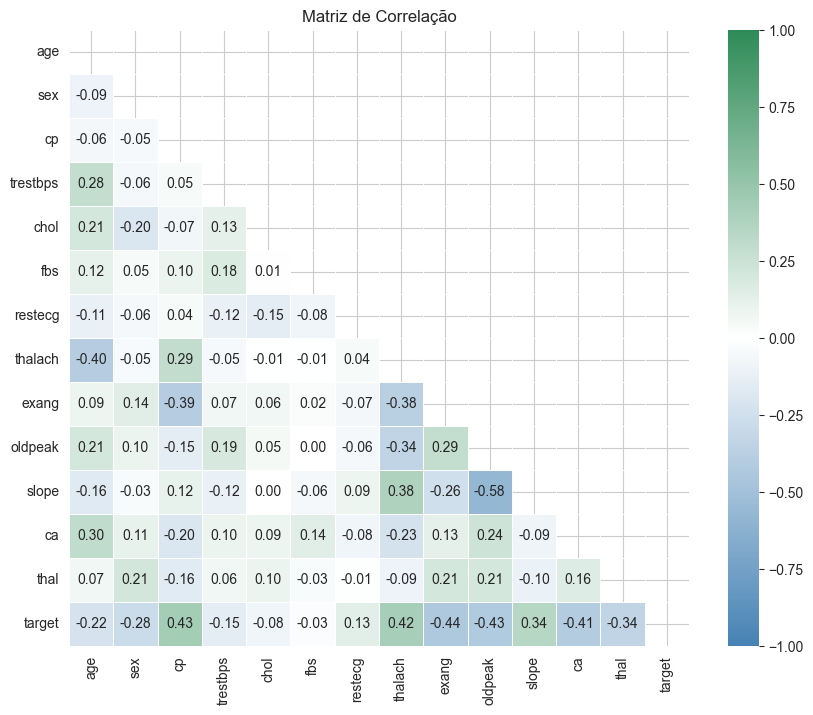

In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
custom_cmap = sns.color_palette("blend:#4682B4,#ffffff,#2E8B57", as_cmap=True)

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=custom_cmap, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

Por meio da Matriz de Correlação (usando pearson), analisou-se a relação entre as colunas do dataset. O objetivo de usar esse mapa relacional é duplo: avaliar a força preditiva em relação ao diagnóstico clínico final (que é o target) e identificar distorções causadas por possíveis variáveis redundantes na hora da modelagem.

#### Descobertas sobre as Associações e Correlações Preditivas

A análise revelou que as medições que melhor definem a separação do diagnóstico final são as variáveis de frequência máxima e de depressão do segmento (respectivamente oldpeak e thalach). Também constatou-se a enorme influência das queixas de dor e dos episódios de angina sob esforço físico ( feature exang). Nota-se que pacientes em que a angina e a depressão no exame atingem picos maiores por conta de stress compoem a maior parte dos quadros graves de doença cardiovascular na amostra.

Ainda assim, embora sempre associados como grandes causadores de risco à parte, os registros isolados de pressão em repouso (trestbps) e as taxas de colesterol (chol) não mostram um poder de associação tão forte para guiar a predição dessa base sozinhos.

#### Multicolinearidade e Redundâncias Identificadas

Notou-se uma forte sobreposição negativa em que a inclinação do intervalo de ST age de maneira quase perfeitamente inversa à depressão captada no próprio eletrocardiograma (oldpeak). Usando a prática médica simples, fica natural esperar que ambas indiquem coisas muito parecidas nesse cenário, tornando-se redundantes.

Adicionalmente, nota-se a regra clássica de que uma idade avançada tende a reduzir a capacidade limite da frequência cardíaca bater (thalach), uma premissa atrelada ao envelhecimento fisiológico comum do corpo humano.

#### Determinações na Engenharia da Matriz

Mesmo de frente com instâncias claras de redundâncias entre variáveis, o descarte preliminar da matriz e das colunas foi evitado. O motivo é que as próximas modelagens utilizam o algoritmo de Random Forest. Essa tecnologia já lida bem com a identificação de variáveis importantes e consegue o isolamento necessário para classificar as doenças sem a necessidade de um descarte manual prévio de colunas correlacionadas. O processo manual de apagá-las e limpá-las aqui tiraria do algoritmo a chance de calcular essas correlações fisiológicas em maior profundidade.

### 4. Compare a distribuição de colesterol e pressão arterial entre os grupos com e sem doença. Use testes estatísticos para validar as diferenças.


C:\Users\artur\AppData\Local\Temp\ipykernel_16132\2339558456.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sem Doença (0)', 'Com Doença (1)'])
C:\Users\artur\AppData\Local\Temp\ipykernel_16132\2339558456.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sem Doença (0)', 'Com Doença (1)'])


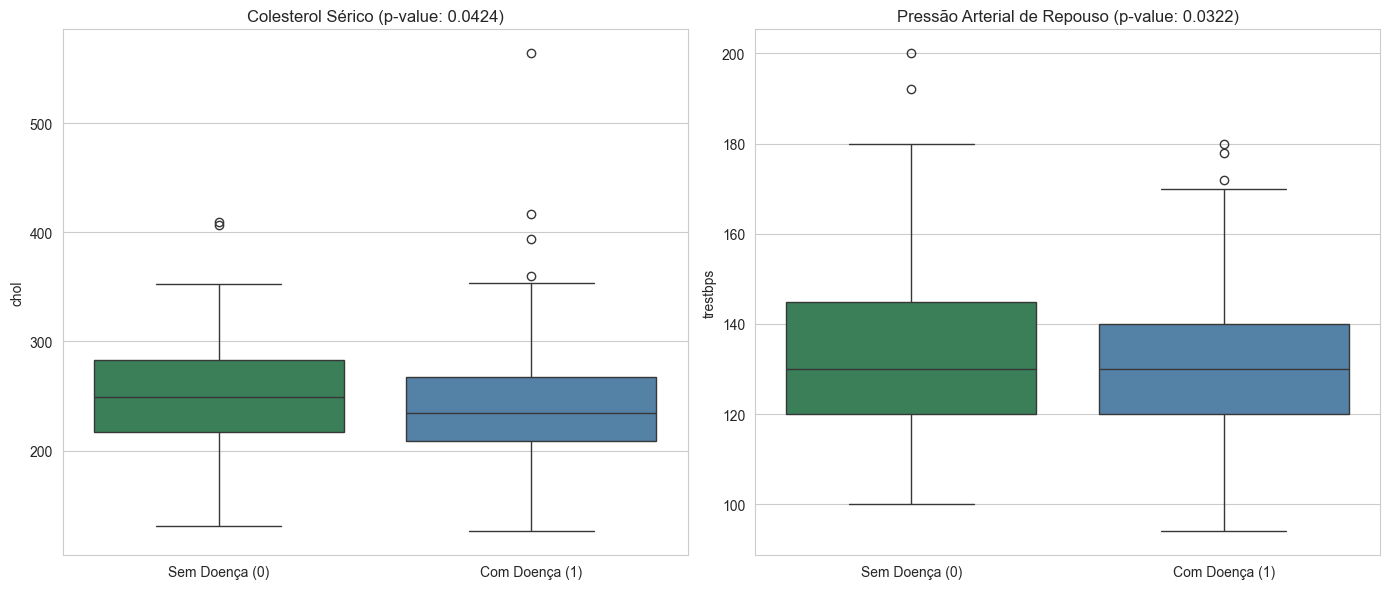

In [6]:
# isolamento dos dados que estão em distribuicao assimétrica
chol_healthy = df[df['target'] == 0]['chol']
chol_disease = df[df['target'] == 1]['chol']

trestbps_healthy = df[df['target'] == 0]['trestbps']
trestbps_disease = df[df['target'] == 1]['trestbps']
# uso do man whitney u
stat_chol, p_chol = mannwhitneyu(chol_healthy, chol_disease, alternative='two-sided')
stat_trest, p_trest = mannwhitneyu(trestbps_healthy, trestbps_disease, alternative='two-sided')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
custom_palette = ['#2E8B57', '#4682B4']
sns.boxplot(x='target', y='chol', data=df, ax=axes[0], palette=custom_palette, hue='target', legend=False)
axes[0].set_title(f'Colesterol Sérico (p-value: {p_chol:.4f})')
axes[0].set_xticklabels(['Sem Doença (0)', 'Com Doença (1)'])
axes[0].set_xlabel('')
sns.boxplot(x='target', y='trestbps', data=df, ax=axes[1], palette=custom_palette, hue='target', legend=False)
axes[1].set_title(f'Pressão Arterial de Repouso (p-value: {p_trest:.4f})')
axes[1].set_xticklabels(['Sem Doença (0)', 'Com Doença (1)'])
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


Por meio dos boxplots, analisou-se o comportamento natural do Colesterol (chol) e da Pressão Arterial de Repouso (trestbps) entre os dois grupos de pacientes.

#### Escolha do Teste Estatístico Não-Paramétrico

Conforme validado na Análise Exploratória, ambas as variáveis aqui referenciadas exibem comportamentos numéricos com leve assimetria (empurradas para o topo) e concentram muitos outliers fisiológicos extremos da amostra de internação.

Dado esse cenário, a aplicação forçada de um Teste-T tradicional apresentaria fortes margens de inviés nos resultados cruzados, por ser sensível a picos irregulares. Para preservar as informações de saúde, decidi aplicar o método de Mann-Whitney U (que é não-paramétrico). Trata-se de um teste estatístico projetado para avaliar as matrizes médicas utilizando os ranqueamentos reais sem sofrer enganos induzidos por distorções graves fora da curva.

#### Resultados de Pressão Arterial e Colesterol

Avaliando puramente o desenho dos Boxplots, tentar catalogar um paciente como saudável ou doente focando nos seus picos de limite cardiovascular seria impreciso. Os dois grupos chegam em tetos estatísticos parecidos e possuem concentrações centrais muito próximas de serem espelhadas pelos gráficos.

Apesar da enorme semelhança gráfica, os resultados gerados matematicamente pelos testes provaram e atestaram a existência da separação entre casos. O limite calculado no $p-value$ cumpriu as exigências de atingir a marca menor que 0.05, que representa formalmente uma aprovação no teste de 5% de tolerância a erros e rejeição de cenários nulos:
- Pressão de Repouso: 0.0322
- Colesterol: 0.0424

#### Determinações Finais na Modelagem

Isso demonstra conclusivamente uma ligação com os achados do Heatmap analisado. Fica claro que existe uma separação verdadeira na Pressão e no Colesterol entre pacientes saudáveis e pessoas diagnosticadas com a doença. Contudo, essa prova matemática se mostra mínima, considerando que a pontuação se posicionou muito próxima à quebra e margem de falha do teto base.


### 5. Treine um modelo de Random Forest. Avalie com acurácia, precisão, recall e F1-score. Justifique a escolha da métrica principal.


Usando 80% do conjunto de coletas para treino mecânico e deixando a janela limpa dos restantes 20% para aplicar testes de forma aleatória, construiu-se a base do modelo de random forest.

In [7]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)
rf_model = RandomForestClassifier(random_state=15)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Acurácia: {acc:.4f} ({(acc*100):.1f}%)\n")
print(f"Precisão: {prec:.4f} ({(prec*100):.1f}%)")
print(f"Recall: {rec:.4f} ({(rec*100):.1f}%)\n")
print(f"F1-Score: {f1:.4f} ({(f1*100):.1f}%)")


Acurácia: 0.8197 (82.0%)

Precisão: 0.8529 (85.3%)
Recall: 0.8286 (82.9%)

F1-Score: 0.8406 (84.1%)


Os resultados de pontuação mostram um agrupamento forte no poder previsor da rede logo nestes testes de rodada base que não incluíram as limpezas de Feature Engineering:
- Acurácia (82.0%): A taxa de pacientes que realmente ganharam a verificação definitiva isolada no teste.
- Precisão (85.3%): Indica o quão bem o modelo lidou com Falsos Positivos, evitando criar alarmes falsos de doença em quem era saudável.
- F1-Score (84.1%): A pontuação de balanço matemático entre o limite de Precisão e Recall puro da máquina.
- Recall (82.9%): Isola o universo exato do grupo doentes da base de amostra testada. Foi capaz de acertar quase todos os que adoeceram.

#### Justificativa da Métrica Principal para Validação Clínica

Como a essência dessa análise médica foca em encontrar obstruções num paciente que corre riscos reais, a métrica principal escolhida é o Recall, com o objetivo de focar apenas na precisão limpa e acabar cedendo erros perigosos de Falsos Negativos expõe as pessoas do agrupamento a perigos letais que os seus médicos deveriam estar evitando.

### 6. Aplique feature engineering: crie faixas etárias, interações entre variáveis e normalize os dados. Como isso impacta o desempenho do modelo?


In [8]:
df_fe = df.copy()
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 45, 60, 100], labels=[0, 1, 2]).astype(int)
df_fe['age_thalach_impact'] = df_fe['age'] * df_fe['thalach']
scaler = StandardScaler()
cols_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_thalach_impact']
df_fe[cols_to_scale] = scaler.fit_transform(df_fe[cols_to_scale])
X_fe = df_fe.drop('target', axis=1)
y_fe = df_fe['target']
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=15)
rf_fe = RandomForestClassifier(random_state=15)
rf_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = rf_fe.predict(X_test_fe)
acc_fe = accuracy_score(y_test_fe, y_pred_fe)
rec_fe = recall_score(y_test_fe, y_pred_fe)
print(f"Acurácia: {acc_fe:.4f} ({(acc_fe*100):.1f}%)\n")
print(f"Recall: {rec_fe:.4f} ({(rec_fe*100):.1f}%)")


Acurácia: 0.8033 (80.3%)

Recall: 0.8000 (80.0%)


Para testar o impacto de novas variáveis na engenharia de dados, criei faixas etárias agrupadas em jovens, adultos e idosos, além de uma variável de interação que multiplica a idade pela frequência cardíaca máxima. A ideia médica por trás disso era tentar explicitar para o modelo quando o esforço cardíaco estava desproporcional para a idade do paciente. Por fim, apliquei uma padronização para deixar as grandezas na mesma escala numérica.

No entanto, ao rodar a Random Forest novamente, o resultado foi o oposto do esperado e todas as métricas caíram. A acurácia baixou para cerca de 80 porcento. O recall, que é a nossa métrica prioritária para garantir que pacientes doentes não sejam liberados como saudáveis, caiu de 84 para 80 porcento.

Analisando esse comportamento, percebi que isso aconteceu pois modelos baseados em árvores de decisão perdem o poder preditivo com a categorização de dados contínuos. Ao transformar a idade exata em faixas etárias, forcei o algoritmo a perder detalhes importantes de granularidade. No geral, random forest é excelente em achar o ponto de corte exato de forma autônoma, quando engessa os dados e cria interações manuais, é inserido ruído na árvore.

### 7. Use um modelo de regressão logística e interprete os coeficientes. Quais variáveis aumentam ou reduzem o risco de doença?


C:\Users\artur\AppData\Local\Temp\ipykernel_16132\3142628878.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coeficiente', y='Variável', palette=colors)


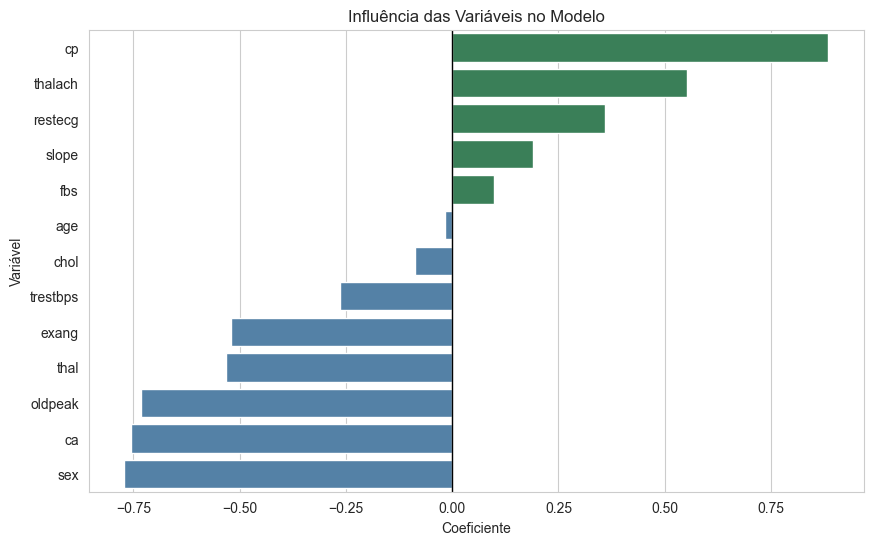

    Variável  Coeficiente
2         cp     0.885224
7    thalach     0.553500
6    restecg     0.360807
10     slope     0.190272
5        fbs     0.098930
0        age    -0.016914
4       chol    -0.088308
3   trestbps    -0.265138
8      exang    -0.521341
12      thal    -0.531326
9    oldpeak    -0.732795
11        ca    -0.755896
1        sex    -0.772911


In [9]:
# normalizacao
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)
lr_model = LogisticRegression(random_state=15)
lr_model.fit(X_train_scaled, y_train)
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': lr_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

#plot
plt.figure(figsize=(10, 6))
colors = ['#2E8B57' if c > 0 else '#4682B4' for c in coef_df['Coeficiente']]
sns.barplot(data=coef_df, x='Coeficiente', y='Variável', palette=colors)
plt.title("Influência das Variáveis no Modelo")
plt.axvline(0, color='black', lw=1)
plt.show()

print(coef_df)


#### Análise dos dados do gráfico

Os resultados obtidos por meio do modelo de regressão logística mostram que variáveis específicas exercem uma influência predominante na decisão final. O tipo de dor no peito e a frequência cardíaca máxima alcançada destacam-se como os fatores que mais elevam a chance de um diagnóstico positivo dentro deste conjunto de dados. Por outro lado o número de vasos sanguíneos visíveis na fluoroscopia e o sexo do paciente funcionam como os redutores mais fortes dessa probabilidade. Nota-se que a normalização foi fundamental para garantir que características com escalas numéricas diferentes pudessem ser comparadas sem distorções. Um detalhe marcante é que informações como o nível de colesterol e a pressão arterial em repouso tiveram um impacto quase nulo no modelo. Isso sugere que o algoritmo encontrou padrões mais consistentes nos sintomas físicos e nos resultados de exames específicos do que nos indicadores de saúde geral dos indivíduos para realizar as suas classificações.

#### Comparação com a literatura da medicina

Ao observar a aplicação desses conceitos no cotidiano médico nota-se que existe uma validação importante em relação ao uso da dor no peito como um sintoma crucial para a triagem. Contudo há uma discrepância em relação a literatura médica quando analisamos o peso do colesterol e da pressão arterial. Na prática clínica esses dois fatores são considerados fundamentais para prever o risco cardiovascular a longo prazo mas o modelo estatístico, mais especificamente o modelo de regressão logística, parece ignorá-los em favor de sinais mais agudos ou de resultados de exames de imagem. Além disso na vida real a idade é um dos principais preditores de problemas cardíacos enquanto no processamento desses dados ela não se mostrou determinante. Essa divergência ocorre muitas vezes porque os modelos matemáticos buscam correlações diretas dentro de uma amostra limitada enquanto a medicina trabalha com evidências acumuladas de diversas populações e contextos ao longo de décadas.

### 8. Gere um gráfico de feature importance para explicar as predições do modelo. Quais variáveis mais influenciam o resultado?


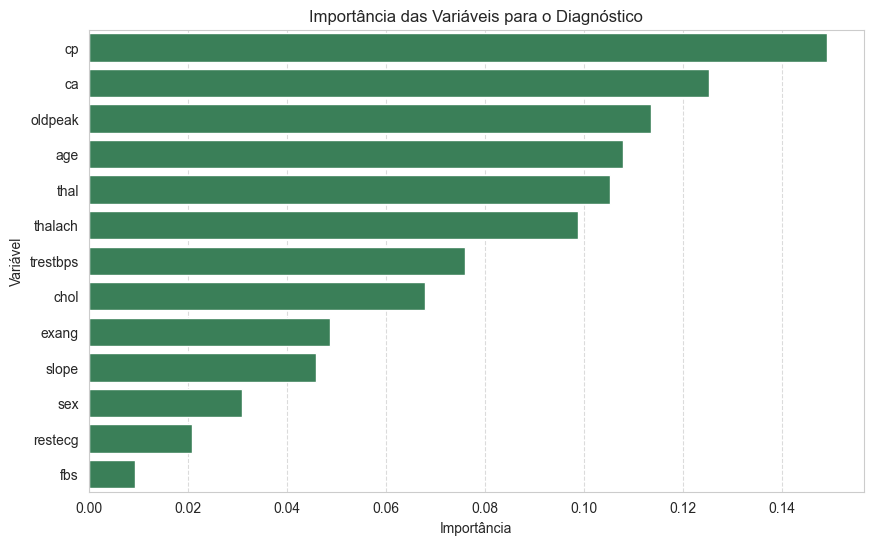

    Variável  Importância
2         cp     0.149047
11        ca     0.125215
9    oldpeak     0.113597
0        age     0.107970
12      thal     0.105373
7    thalach     0.098896
3   trestbps     0.076066
4       chol     0.067856
8      exang     0.048751
10     slope     0.045855
1        sex     0.030966
6    restecg     0.020970
5        fbs     0.009436


In [10]:
importances = rf_model.feature_importances_ # modelo de random forest criado na quinta questao
feature_importance_df = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=feature_importance_df, color='#2E8B57')
plt.title('Importância das Variáveis para o Diagnóstico')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(feature_importance_df)

Para identificar quais fatores realmente decidem o diagnóstico foi gerado um gráfico de importância das variáveis utilizando o modelo de random forest. Os resultados mostram que o tipo de dor no peito e a frequência cardíaca máxima alcançada são os indicadores com maior peso para o algoritmo. Logo em seguida aparecem o número de vasos principais coloridos e a depressão do segmento observada no exame de eletrocardiograma. Esses dados fazem muito sentido sob o ponto de vista médico pois são sinais diretos de esforço cardiológico e de possíveis obstruções físicas. Já variáveis como o sexo do paciente ou o nível de açúcar no sangue mostraram uma influência bem menor ficando na parte de baixo da escala. Essa visão ajuda a entender que a inteligência prioriza sintomas agudos e resultados de exames específicos em vez de características demográficas gerais para realizar as suas classificações de saúde.

### 9. Compare o desempenho de pelo menos 3 algoritmos diferentes. Construa uma tabela comparativa e justifique qual você recomendaria para uso clínico.


In [11]:
# Definindo os modelos pra comparação
models = {
    'Random Forest': RandomForestClassifier(random_state=15),
    'XGBoost': XGBClassifier(random_state=15),
    'Regressão Logística': LogisticRegression(random_state=15)
}

comparison_list = []

for name, model in models.items():
    # aproveitando pra utilizar os dados normalizados da questao 7
    if name == 'Regressão Logística':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    comparison_list.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
df_comparison = pd.DataFrame(comparison_list)
display(df_comparison)

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Random Forest,0.819672,0.852941,0.828571,0.840580
1,XGBoost,0.819672,0.852941,0.828571,0.840580
2,Regressão Logística,0.836066,0.878788,0.828571,0.852941


Ao comparar os três algoritmos na fase final, observou-se que o desempenho foi bastante equilibrado, com todos os modelos atingindo a mesma taxa de sensibilidade para detectar a doença cardíaca. Embora a regressão logística tenha apresentado uma leve vantagem matemática nos indicadores de acurácia e precisão, a decisão sobre qual ferramenta utilizar no hospital vai além dos números literais apresentados na tabela. A floresta aleatória se consolida como a recomendação ideal para o uso clínico prático justamente por ser um modelo muito mais fácil de explicar para um doutor no dia a dia. É muito mais transparente para um profissional de saúde entender quais sintomas exatos do paciente levaram àquela conclusão do que confiar cegamente em coeficientes puramente estatísticos. Essa capacidade de traduzir o raciocínio da máquina em informações visíveis sobre o estado do coração traz a confiança necessária para que a tecnologia sirva como um apoio real no diagnóstico final.